## Pre - Processing 

### Patient-Based Partitioning 
- The BEED dataset from the UCI repository is in a tabular format, so every 200 lines represents one patient. Patient-Based Partitioning will be used to ensure that a patient doesn't end up in more than one place. 

### Channel-Wise Z-Score Normalization
- EEG amplitude levels natively vary across channels, so unscaled features can distort weight updates and slow down training. Standardization centers the data $(X_{\text{norm}} = \frac{X - \mu}{\sigma})$ so every channel contributes equally to gradient descent.


In [3]:
import pandas as pd 

# Load data into a DataFrame
df = pd.read_csv("BEED_Data.csv")

# Create a 'Patient_ID' column
df['Patient_ID'] = df.index // 100 + 1

# Define the target column name
target_column = 'y'

print(f"Data loaded successfully: {len(df)} rows, {df['Patient_ID'].nunique()} patients")


Data loaded successfully: 8000 rows, 80 patients


In [5]:
from sklearn.model_selection import train_test_split

# Extract unique patient IDs and their corresponding labels
patient_df = df.groupby('Patient_ID')['y'].first().reset_index()

# Isolate the 15% Test Patients (12 patients: 3 per class)
train_val_patients, test_patients = train_test_split(patient_df, test_size=12, random_state=42, stratify=patient_df['y'])

# Divide up the Train/Validation Set (70% Train, 15% Validation)
train_patients, val_patients = train_test_split(train_val_patients, test_size=12, random_state=42, stratify=train_val_patients['y'])

# filter the original DataFrame by patient assignments
train_df = df[df['Patient_ID'].isin(train_patients['Patient_ID'])].reset_index(drop=True)
val_df = df[df['Patient_ID'].isin(val_patients['Patient_ID'])].reset_index(drop=True)
test_df = df[df['Patient_ID'].isin(test_patients['Patient_ID'])].reset_index(drop=True)


# Extract Patient IDs for Leakage Check
train_p_set = set(train_df['Patient_ID'])
val_p_set = set(val_df['Patient_ID'])
test_p_set = set(test_df['Patient_ID'])

# Trigger error if there are overlapping patients
assert (
    len(train_p_set.intersection(val_p_set)) == 0
    and len(train_p_set.intersection(test_p_set)) == 0
    and len(val_p_set.intersection(test_p_set)) == 0
), "Overlap between Train, Validation, and Test sets"

print("No overlapping patients between Train, Validation, and Test sets. Data splitting successful.")

# Print verification summary 
print("--- Patient Distribution Summary ---")
print(
    f"Train:      {len(train_p_set)} patients ({len(train_df)} rows,"
    f" {len(train_df)/len(df):.0%})"
)
print(
    f"Validation: {len(val_p_set)} patients ({len(val_df)} rows,"
    f" {len(val_df)/len(df):.0%})"
)
print(
    f"Test:       {len(test_p_set)} patients ({len(test_df)} rows,"
    f" {len(test_df)/len(df):.0%})"
)

print("\n--- CLASS DISTRIBUTION IN TEST SET ---")
print(test_df[target_column].value_counts().sort_index())


No overlapping patients between Train, Validation, and Test sets. Data splitting successful.
--- Patient Distribution Summary ---
Train:      56 patients (5600 rows, 70%)
Validation: 12 patients (1200 rows, 15%)
Test:       12 patients (1200 rows, 15%)

--- CLASS DISTRIBUTION IN TEST SET ---
y
0    300
1    300
2    300
3    300
Name: count, dtype: int64


In [6]:
# Z-Score Normalization

from sklearn.preprocessing import StandardScaler
import torch 
from torch.utils.data import DataLoader, TensorDataset
scaler = StandardScaler()

# Define target column and feature columns
target_column = 'y'
feature_columns = [col for col in df.columns if col != target_column and col != 'Patient_ID']

# fit scaler ONLY on training data to prevent data leakage
X_train= scaler.fit_transform(train_df[feature_columns].values)
y_train = train_df[target_column].values

X_val = scaler.transform(val_df[feature_columns].values)
y_val = val_df[target_column].values

X_test = scaler.transform(test_df[feature_columns].values)
y_test = test_df[target_column].values

# Convert the scaled data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

print("Data loading complete. Train, Validation, and Test DataLoaders are ready.")

Data loading complete. Train, Validation, and Test DataLoaders are ready.


## Model Creation

In [7]:
# Create the model for categorical classification
from torch import nn
from torch.nn import functional as F

class SeizureNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 128),  # 16 input features
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 4)  # Output layer for categorical classification
        )
    def forward(self, x):
        logits = self.network(x)
        return logits  # Return logits for CrossEntropyLoss

## Choose Loss function and Optimizer

In [8]:
## Choosing loss function and optimizer

model = SeizureNet()  # Instantiate the model

loss_fn = nn.CrossEntropyLoss()  # For categorical classification
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)  # Using AdamW optimizer with a learning rate of 0.001


## Training/Testing Loop

In [9]:
from sklearn.metrics import confusion_matrix, f1_score

# Create train method 
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()  # Set the model to training mode

    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)  # Ensure y is of type long for CrossEntropyLoss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Print progress every 30 batches
        if batch % 30 == 0:
            current = batch * len(X)
            print(f"loss: {loss:>7f}  [{round(current*100/size, 3)}%]")

def eval_loop(dataloader, model, loss_fn):
    model.eval()  # Set the model to evaluation mode
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    correct = 0
    total_loss = 0.0

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            total_loss += loss_fn(pred, y).item()

            preds = pred.argmax(dim=1)
            correct += (preds == y).type(torch.float).sum().item()

            all_preds.extend(preds.tolist())
            all_targets.extend(y.tolist())

    avg_loss = total_loss / num_batches
    accuracy = correct / size
    macro_f1 = f1_score(all_targets, all_preds, average='macro')

    cm = confusion_matrix(all_targets, all_preds)

    print(f"Accuracy: {accuracy:.4f} | Macro F1 Score: {macro_f1:.4f} | Average Loss: {avg_loss:.4f}")
    return accuracy, macro_f1, avg_loss, cm

## Choosing # of Epochs and training the model

Epoch 1

loss: 1.376432  [0.0%]
loss: 1.048910  [34.286%]
loss: 0.723014  [68.571%]
Train: Accuracy: 0.6911 | Macro F1 Score: 0.6918 | Average Loss: 0.7831
Val: Accuracy: 0.5817 | Macro F1 Score: 0.5747 | Average Loss: 0.8254
Best model weights saved based on validation loss.
--------------------------------

Epoch 2

loss: 0.720455  [0.0%]
loss: 0.766779  [34.286%]
loss: 0.675832  [68.571%]
Train: Accuracy: 0.7273 | Macro F1 Score: 0.6866 | Average Loss: 0.5773
Val: Accuracy: 0.7358 | Macro F1 Score: 0.6855 | Average Loss: 0.7103
Best model weights saved based on validation loss.
--------------------------------

Epoch 3

loss: 0.565147  [0.0%]
loss: 0.454197  [34.286%]
loss: 0.487678  [68.571%]
Train: Accuracy: 0.7950 | Macro F1 Score: 0.7939 | Average Loss: 0.4823
Val: Accuracy: 0.6917 | Macro F1 Score: 0.6809 | Average Loss: 0.7229
--------------------------------

Epoch 4

loss: 0.516025  [0.0%]
loss: 0.399540  [34.286%]
loss: 0.311942  [68.571%]
Train: Accuracy: 0.8113 | Macro F1

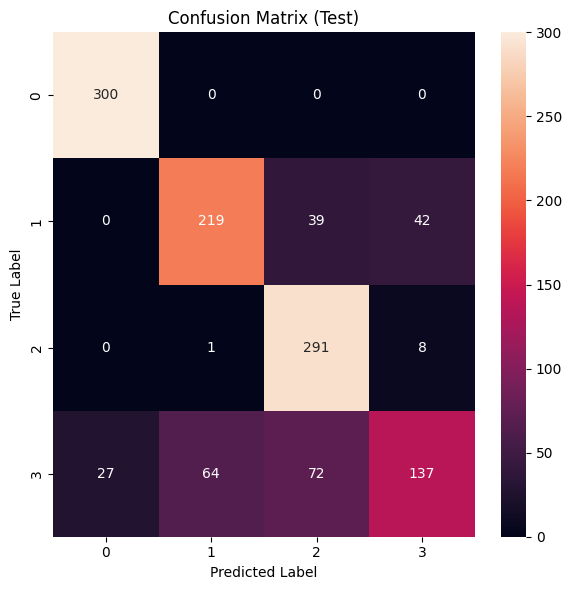

In [10]:
# Reintialize 
model = SeizureNet()  # Re-instantiate the model
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)  # Re-instantiate the optimizer

#training/early stopping
epochs = 50
best_val_loss = float('inf')
patience = 7  # Number of epochs to wait for improvement before stopping
patience_counter = 0  # Counter for early stopping

for t in range(epochs):
    print(f"Epoch {t+1}\n")

    #Train model on train data (update params)
    train_loop(train_loader, model, loss_fn, optimizer)

    print("Train: ", end="")
    eval_loop(train_loader, model, loss_fn)

    print("Val: ", end="")
    val_acc, val_f1, val_loss, val_cm = eval_loop(val_loader, model, loss_fn)

    #Track and save best baseline weights based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0  # Reset patience counter if validation loss improves
        torch.save(model.state_dict(), "best_model_weights.pth")
        print("Best model weights saved based on validation loss.")
    else: 
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping baseline run at Epoch {t+1}!")
            break

    print("--------------------------------\n")
print("Training complete!")

# Evaluate the best model on the test set
model.load_state_dict(torch.load("best_model_weights.pth"))  # Load the best model weights
print("\n=== Evaluating Best Model on Test Set ===")
test_acc, test_f1, test_loss, test_cm = eval_loop(test_loader, model, loss_fn)

# Plot annotated confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns   

plt.figure(figsize=(6,6))
class_labels = sorted(df[target_column].unique())

sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Print Loss Curves

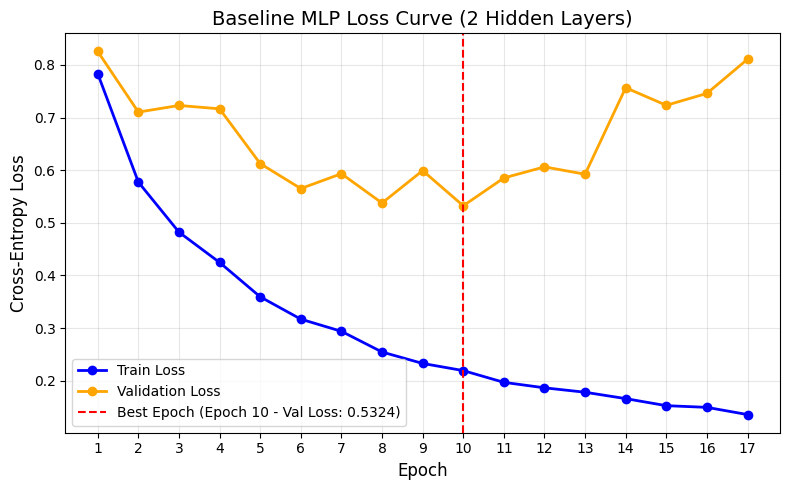

In [2]:
import matplotlib.pyplot as plt

# Epoch loss values extracted from the baseline run console output
train_losses = [
    0.7831, 0.5773, 0.4823, 0.4248, 0.3595, 0.3171, 0.2940, 0.2547, 
    0.2330, 0.2194, 0.1971, 0.1867, 0.1783, 0.1662, 0.1528, 0.1496, 0.1359
]

val_losses = [
    0.8254, 0.7103, 0.7229, 0.7165, 0.6125, 0.5651, 0.5933, 0.5376, 
    0.5992, 0.5324, 0.5852, 0.6063, 0.5923, 0.7566, 0.7232, 0.7458, 0.8107
]

epochs = list(range(1, len(train_losses) + 1))

# Plotting Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss", color="blue", linewidth=2, marker='o')
plt.plot(epochs, val_losses, label="Validation Loss", color="orange", linewidth=2, marker='o')
plt.axvline(
    x=10,
    color="red",
    linestyle="--",
    label="Best Epoch (Epoch 10 - Val Loss: 0.5324)",
)

plt.title("Baseline MLP Loss Curve (2 Hidden Layers)", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
